## Load data

In [6]:
import torch
from brain_image.data.io import batch_load_images
from src.brain_image.data.dataset.things_eeg2_dataset import ThingsEEG2Dataset, ThingsEEG2DatasetConfig

dataset_config = ThingsEEG2DatasetConfig(subs=[1], preload_cache=False)
dataset = dataset_config.create_dataset(split="test", embeddings_key_to_name={"clip_img_latent": "clip_vitl14", "unaligned_synclr_img_latent": "unaligned_synclr_vitb16", "aligned_synclr_img_latent": "aligned_synclr_vitb16"})

In [7]:
NUM_SAMPLES = 200
eeg = torch.stack([dataset[i]["eeg_data"] for i in range(NUM_SAMPLES)], dim=0)
img_paths = [dataset[i]["img_path"] for i in range(NUM_SAMPLES)]
img = batch_load_images(img_paths)
clip_img = torch.stack([dataset[i]["clip_img_latent"] for i in range(NUM_SAMPLES)], dim=0)
unaligned_synclr_img = torch.stack([dataset[i]["unaligned_synclr_img_latent"] for i in range(NUM_SAMPLES)], dim=0)
aligned_synclr_img = torch.stack([dataset[i]["aligned_synclr_img_latent"] for i in range(NUM_SAMPLES)], dim=0)

print(eeg.shape)
print(img.shape)
print(clip_img.shape)
print(unaligned_synclr_img.shape)
print(aligned_synclr_img.shape)

torch.Size([200, 63, 250])
torch.Size([200, 3, 500, 500])
torch.Size([200, 768])
torch.Size([200, 768])
torch.Size([200, 768])


## Caption images

In [8]:
import asyncio
import json
import logging
from pathlib import Path

import tqdm

import base64
from openai import AsyncOpenAI
from pathlib import Path
import os
import dotenv

In [26]:

dotenv.load_dotenv()
client = AsyncOpenAI(api_key=os.environ["OPENAI_API_KEY"])

logging.basicConfig(level=logging.DEBUG)
logger = logging.getLogger(__name__)


def encode_image(image_path: Path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


async def caption_image(
    client,
    image_path: Path,
    configs,
    **kwargs
):
    configs = {**configs, **kwargs}

    base64_image = encode_image(image_path)
    label = ' '.join(image_path.stem.split("_")[:-1])
    logger.debug(f"Captioning image: {image_path}, label: {label}")

    response = await client.responses.create(
        model=configs["model"],
        instructions=configs["system_prompt"],
        max_output_tokens=configs["max_tokens"],
        input=[
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": label},
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{base64_image}",
                    },
                ],
            },
        ],
    )

    logger.debug(f"Response id: {response.id}")
    logger.debug(f"Response status: {response.status}")
    logger.debug(f"Response output: {response.output}")
    logger.debug(f"Response output_text: {repr(response.output_text)}")

    return {
        "text": response.output_text,
        "configs": configs,
    }


def load_existing_paths(jsonl_path: Path):
    if not jsonl_path.exists():
        return set()

    existing = set()
    with open(jsonl_path, "r") as f:
        for line in f:
            entry = json.loads(line)
            existing.add(entry["path"])
    return existing


async def process_one(
    semaphore,
    client,
    img_path: str,
    configs,
):
    async with semaphore:
        result = await caption_image(
            client,
            Path(img_path),
            configs=configs
        )
        return img_path, result


async def generate_captions_async(
    client,
    img_paths,
    configs,
    caption_path=Path("data/things-eeg2/captions/default.jsonl"),
    max_concurrency=8,
):
    logging.info(f"Captioning {len(img_paths)} images with max concurrency {max_concurrency}. Writing results to {caption_path}.")
    logging.info(f"Configs:")
    for key, value in configs.items():
        logging.info(f"  {key}: {value}")

    caption_path.parent.mkdir(parents=True, exist_ok=True)

    existing = load_existing_paths(caption_path)

    original_len = len(img_paths)
    img_paths = [str(p) for p in img_paths if str(p) not in existing]
    logging.info(f"Processing {len(img_paths)} out of {original_len} images. Skipped {original_len - len(img_paths)} existing captions.")

    semaphore = asyncio.Semaphore(max_concurrency)

    tasks = [
        asyncio.create_task(
            process_one(semaphore, client, img_path, configs)
        )
        for img_path in img_paths
    ]

    with open(caption_path, "a") as f, tqdm.tqdm(total=len(tasks), desc="Generating captions") as pbar:
        for task in asyncio.as_completed(tasks):
            try:
                img_path, result = await task

                json.dump({
                    "path": img_path,
                    "caption": result["text"],
                    "configs": result["configs"],
                }, f)
                f.write("\n")
                f.flush()

                pbar.update(1)

            except Exception as e:
                print(f"Failed: {e}")


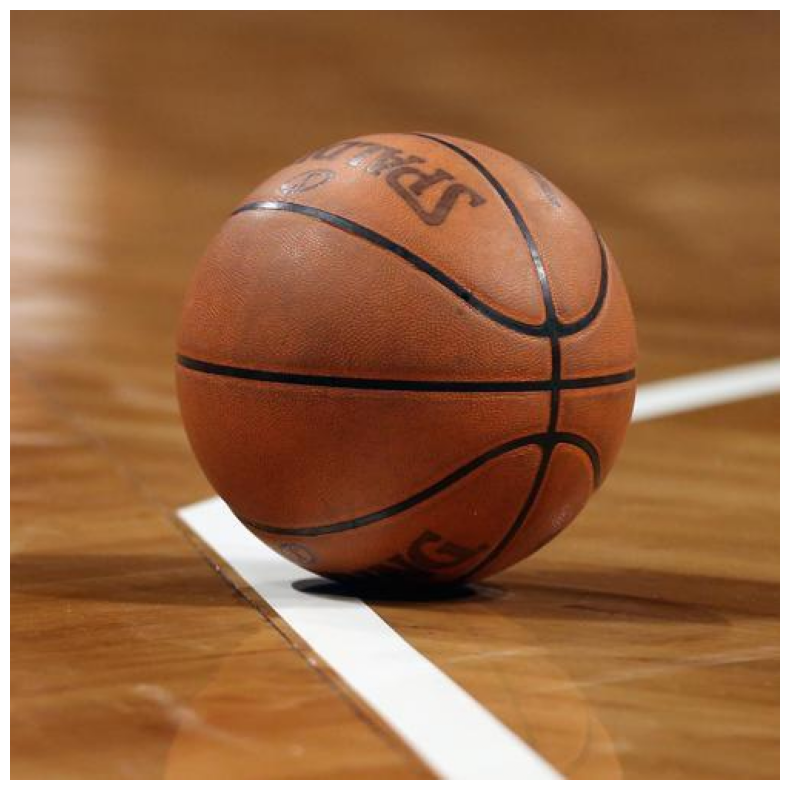

In [27]:
from brain_image.utils import show_image


ex_path= "data/things-eeg2/imgs/test_images/00008_basketball/basketball_05s.jpg"
ex_img = batch_load_images([ex_path])

show_image(ex_img[0] / 255.)

In [31]:

import logging
import sys

logging.basicConfig(
    level=logging.INFO,
    force=True,
    handlers=[logging.StreamHandler(sys.stdout)],
)

system_prompt = """You are given an image. Generate a single, detailed caption for the caption. 
You are given an object class label for the image, which is the object in the image that the caption should describe.
The caption must be visually precise, descriptive, and neutral. 
Do not assume any prior context. 
Avoid storytelling, interpretation, or emotional language. 
Describe only what is clearly visible.
Example: An [X] in a [Y]. The [X] is a [object] with [visual attributes] [located at [position] of [Y] in the [local position] of the image. [Y] is an [object] with [visual attributes].
"""

configs = {
    "system_prompt": system_prompt,
    "user_prompt": "Describe this image.",
    "model": "gpt-5-nano",
    "max_tokens": 4096,
}

#await caption_image(
#    client,
#    Path(ex_path),
#    configs=configs
#)


In [ ]:
asyncio.gather(generate_captions_async(client, img_paths, configs, caption_path=Path("data/things-eeg2/captions/default.jsonl"), max_concurrency=8))

<_GatheringFuture pending>

INFO:root:Captioning 200 images with max concurrency 8. Writing results to data/things-eeg2/captions/default.jsonl.
INFO:root:Configs:
INFO:root:  system_prompt: You are given an image. Generate a single, detailed caption for the caption. 
You are given an object class label for the image, which is the object in the image that the caption should describe.
The caption must be visually precise, descriptive, and neutral. 
Do not assume any prior context. 
Avoid storytelling, interpretation, or emotional language. 
Describe only what is clearly visible.
Example: An [X] in a [Y]. The [X] is a [object] with [visual attributes] [located at [position] of [Y] in the [local position] of the image. [Y] is an [object] with [visual attributes].

INFO:root:  user_prompt: Describe this image.
INFO:root:  model: gpt-5-nano
INFO:root:  max_tokens: 4096
INFO:root:Processing 200 out of 200 images. Skipped 0 existing captions.


Generating captions:   0%|          | 0/200 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


Generating captions:   0%|          | 1/200 [00:07<23:53,  7.21s/it]

...

Generating captions:  99%|█████████▉| 198/200 [04:06<00:02,  1.01s/it]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


Generating captions: 100%|█████████▉| 199/200 [04:09<00:01,  1.54s/it]

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


Generating captions: 100%|██████████| 200/200 [04:11<00:00,  1.26s/it]


In [ ]:
def load_text_captions(caption_path: Path):
    captions = {}
    with open(caption_path, "r") as f:
        for line in f:
            entry = json.loads(line)
            captions[entry["path"]] = entry["caption"]
    return captions

captions = load_text_captions(Path("data/things-eeg2/captions/default.jsonl"))
captions

{'data/things-eeg2/imgs/test_images/00008_basketball/basketball_05s.jpg': '',
 'data/things-eeg2/imgs/test_images/00005_banana/banana_09s.jpg': '',
 'data/things-eeg2/imgs/test_images/00006_baseball_bat/baseball_bat_10s.jpg': '',
 'data/things-eeg2/imgs/test_images/00007_basil/basil_05s.jpg': '',
 'data/things-eeg2/imgs/test_images/00002_antelope/antelope_01b.jpg': '',
 'data/things-eeg2/imgs/test_images/00004_balance_beam/balance_beam_04s.jpg': '',
 'data/things-eeg2/imgs/test_images/00003_backscratcher/backscratcher_01b.jpg': '',
 'data/things-eeg2/imgs/test_images/00001_aircraft_carrier/aircraft_carrier_06s.jpg': '',
 'data/things-eeg2/imgs/test_images/00009_bassoon/bassoon_01b.jpg': '',
 'data/things-eeg2/imgs/test_images/00011_batter/batter_01b.jpg': '',
 'data/things-eeg2/imgs/test_images/00010_baton4/baton4_05s.jpg': '',
 'data/things-eeg2/imgs/test_images/00015_birthday_cake/birthday_cake_01b.jpg': '',
 'data/things-eeg2/imgs/test_images/00012_beaver/beaver_04s.jpg': '',
 'data

## Generate embeddings

### Text Embeddings

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [ ]:
import tqdm
from brain_image.model.encoder.text_encoder.text_encoder import T5TextEncoder, CLIPTextEncoder, GemmaTextEncoder
from brain_image.model.encoder.text_encoder.union import load_text_encoder


def encode_texts(text_encoder, captions: list[str], batch_size: int = 128, device: torch.device | None = None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    text_encoder.to(device)
    all_embeddings = []
    for i in tqdm.tqdm(range(0, len(captions), batch_size), desc="Encoding captions"):
        batch_captions = captions[i : i + batch_size]
        embedding = text_encoder.encode(batch_captions)
        all_embeddings.append(embedding.cpu())
    return torch.cat(all_embeddings, dim=0)


enc_t5 = T5TextEncoder()
enc_clip_text = CLIPTextEncoder()
enc_gemma = GemmaTextEncoder()
captions_list = [captions[path] for path in img_paths]
text_t5 = encode_texts(enc_t5, captions_list)
text_clip = encode_texts(enc_clip_text, captions_list)
text_gemma = enc_gemma.encode(captions_list)

print(text_t5.shape)
print(text_clip.shape)
print(text_gemma.shape)


Encoding captions: 100%|██████████| 2/2 [00:00<00:00,  6.68it/s]

torch.Size([200, 768])
torch.Size([200, 768])


In [84]:
ex_caption = captions[img_paths[0]]
print("Caption:", ex_caption)

tokenized = enc_t5.tokenize([ex_caption])
print("Tokenized:", tokenized)

detokenized = enc_t5.tokenizer.batch_decode(tokenized["input_ids"], skip_special_tokens=True)
print("Detokenized:", detokenized)

Caption: An aircraft carrier ship with the hull number "A12" is sailing on the ocean. The ship has a large flat deck with a runway marked with white lines and a control tower structure rising from the deck near the center. The ship is gray in color and is creating a wake as it moves through the water. The sky above is clear with a slight haze.
Tokenized: {'input_ids': tensor([[  389,  6442,  9568,  4383,    28,     8,     3, 22699,   381,    96,
           188,  2122,   121,    19, 16132,    30,     8,  5431,     5,    37,
          4383,    65,     3,     9,   508,  2667,  3854,    28,     3,     9,
         22750,  7027,    28,   872,  2356,    11,     3,     9,   610,  7293,
          1809,  6937,    45,     8,  3854,  1084,     8,  1530,     5,    37,
          4383,    19,  9954,    16,   945,    11,    19,  1577,     3,     9,
          7178,    38,    34,  6914,   190,     8,   387,     5,    37,  5796,
           756,    19,   964,    28,     3,     9,  9927,     3, 10557,    1

## Experiments

### Canonical Correlation Analysis (CKA)

In [16]:
# RBF kernel
def rbf_kernel(x, sigma=None):    
    pairwise_dists = torch.cdist(x, x, p=2)

    if sigma is None: # median heuristic
        mask = ~torch.eye(x.size(0), dtype=torch.bool, device=x.device)
        sigma = pairwise_dists[mask].median()

    K = torch.exp(-pairwise_dists ** 2 / (2 * sigma ** 2))
    return K

def center_gram(G):
    mean_row = G.mean(0, keepdim=True)
    mean_col = G.mean(1, keepdim=True)
    mean_all = G.mean()
    return G - mean_row - mean_col + mean_all


def centered_kernel_alignment(X, Y, kernel = "rbf"):
    X = X.flatten(1)
    Y = Y.flatten(1)

    if kernel == "rbf":
        Gx = rbf_kernel(X)
        Gy = rbf_kernel(Y)
    else:
        raise ValueError(f"Unsupported kernel: {kernel}")

    Gx = center_gram(Gx)
    Gy = center_gram(Gy)

    hsic_xy = (Gx * Gy).sum()
    hsic_xx = (Gx * Gx).sum()
    hsic_yy = (Gy * Gy).sum()

    return hsic_xy / torch.sqrt(hsic_xx * hsic_yy)

def pca_reduce(X, k=100):
    X = X - X.mean(0)
    U, S, Vh = torch.linalg.svd(X, full_matrices=False)
    return U[:, :k] * S[:k]


def canonical_correlation_analysis(X, Y, pca_dim: int = 100, eps=1e-8):
    """
    Returns the first canonical correlation coefficient.
    """

    X = X.flatten(1).float()
    Y = Y.flatten(1).float()

    # Center features
    X = X - X.mean(dim=0, keepdim=True)
    Y = Y - Y.mean(dim=0, keepdim=True)

    # PCA reduction
    X = pca_reduce(X, k=pca_dim)
    Y = pca_reduce(Y, k=pca_dim)

    N = X.size(0)

    # Covariance matrices
    Cxx = (X.T @ X) / (N - 1) + eps * torch.eye(X.size(1), device=X.device)
    Cyy = (Y.T @ Y) / (N - 1) + eps * torch.eye(Y.size(1), device=Y.device)
    Cxy = (X.T @ Y) / (N - 1)

    # Whitening
    Ux, Sx, _ = torch.linalg.svd(Cxx)
    Uy, Sy, _ = torch.linalg.svd(Cyy)

    Cxx_inv_sqrt = Ux @ torch.diag(1.0 / torch.sqrt(Sx + eps)) @ Ux.T
    Cyy_inv_sqrt = Uy @ torch.diag(1.0 / torch.sqrt(Sy + eps)) @ Uy.T

    T = Cxx_inv_sqrt @ Cxy @ Cyy_inv_sqrt

    # Singular values of T are canonical correlations
    _, S, _ = torch.linalg.svd(T)

    return S[0]  # first canonical correlation


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eeg = eeg.to(device)
clip_img = clip_img.to(device)
text_clip = text_clip.to(device)
text_t5 = text_t5.to(device)

t5_cka = centered_kernel_alignment(text_t5, eeg)
clip_img_cka = centered_kernel_alignment(clip_img, eeg)
clip_text_cka = centered_kernel_alignment(text_clip, eeg)
t5_cca = canonical_correlation_analysis(text_t5, eeg)
clip_img_cca = canonical_correlation_analysis(clip_img, eeg)
clip_text_cca = canonical_correlation_analysis(text_clip, eeg)

print(f"T5 CKA: {t5_cka.item():.4f}")
print(f"CLIP text CKA: {clip_text_cka.item():.4f}")
print(f"CLIP image CKA: {clip_img_cka.item():.4f}")
print(f"T5 CCA: {t5_cca.item():.4f}")
print(f"CLIP text CCA: {clip_text_cca.item():.4f}")
print(f"CLIP image CCA: {clip_img_cca.item():.4f}")

T5 CKA: 0.3974
CLIP text CKA: 0.4762
CLIP image CKA: 0.4737
T5 CCA: 1.0000
CLIP text CCA: 1.0000
CLIP image CCA: 1.0000


In [22]:
# Repeat for different subs

latents = {
    "text_t5": text_t5.to(device),
    "text_clip": text_clip.to(device),
    "text_gemma": text_gemma.to(device),
    "clip_img": clip_img.to(device),
    "unaligned_synclr_img": unaligned_synclr_img.to(device),
    "aligned_synclr_img": aligned_synclr_img.to(device),
}
eeg = eeg.to(device)
cka_results = {}
cca_results = {}

for sub in range(1, 10):
    dataset_config_sub = ThingsEEG2DatasetConfig(subs=[sub], preload_cache=False)
    dataset_sub = dataset_config_sub.create_dataset(split="test")
    eeg_sub = torch.stack([dataset_sub[i]["eeg_data"] for i in range(NUM_SAMPLES)], dim=0)
    eeg_sub = eeg_sub.to(device)
    
    cka_results[sub] = {}
    cca_results[sub] = {}
    for name, latent in latents.items():
        cka = centered_kernel_alignment(latent, eeg_sub)
        cca = canonical_correlation_analysis(latent, eeg_sub)
        cka_results[sub][name] = cka.item()
        cca_results[sub][name] = cca.item()
        print(f"Sub {sub} - {name} CKA: {cka.item():.4f}")
        print(f"Sub {sub} - {name} CCA: {cca.item():.4f}")

Sub 1 - text_t5 CKA: 0.3974
Sub 1 - text_t5 CCA: 1.0000
Sub 1 - text_clip CKA: 0.4762
Sub 1 - text_clip CCA: 1.0000
Sub 1 - text_gemma CKA: 0.5078
Sub 1 - text_gemma CCA: 1.0000
Sub 1 - clip_img CKA: 0.4737
Sub 1 - clip_img CCA: 1.0000
Sub 1 - unaligned_synclr_img CKA: 0.3689
Sub 1 - unaligned_synclr_img CCA: 1.0000
Sub 1 - aligned_synclr_img CKA: 0.3318
Sub 1 - aligned_synclr_img CCA: 1.0000
Sub 2 - text_t5 CKA: 0.3134
Sub 2 - text_t5 CCA: 1.0000
Sub 2 - text_clip CKA: 0.3859
Sub 2 - text_clip CCA: 1.0000
Sub 2 - text_gemma CKA: 0.4110
Sub 2 - text_gemma CCA: 1.0000
Sub 2 - clip_img CKA: 0.3863
Sub 2 - clip_img CCA: 1.0000
Sub 2 - unaligned_synclr_img CKA: 0.3025
Sub 2 - unaligned_synclr_img CCA: 1.0000
Sub 2 - aligned_synclr_img CKA: 0.2719
Sub 2 - aligned_synclr_img CCA: 1.0000
Sub 3 - text_t5 CKA: 0.4321
Sub 3 - text_t5 CCA: 1.0000
Sub 3 - text_clip CKA: 0.5158
Sub 3 - text_clip CCA: 1.0000
Sub 3 - text_gemma CKA: 0.5451
Sub 3 - text_gemma CCA: 1.0000
Sub 3 - clip_img CKA: 0.5140
S

In [ ]:
mean_cka_results = {name: sum(cka_results[sub][name] for sub in cka_results) / len(cka_results) for name in latents}
std_cka_results = {name: (sum((cka_results[sub][name] - mean_cka_results[name]) ** 2 for sub in cka_results) / len(cka_results)) ** 0.5 for name in latents}

mean_cka_results, std_cka_results

# representative text model
# representative vision model
# representative vlm model

# t5 - language model
# llama - language model
# VLM vs CLIP
# 

({'text_t5': 0.3905944526195526,
  'text_clip': 0.4690385361512502,
  'text_gemma': 0.49712401297357345,
  'clip_img': 0.4673469795121087,
  'unaligned_synclr_img': 0.36208569010098773,
  'aligned_synclr_img': 0.3272630009386275},
 {'text_t5': 0.054495835060163506,
  'text_clip': 0.06041457567047884,
  'text_gemma': 0.06230511383348514,
  'clip_img': 0.058448902551172424,
  'unaligned_synclr_img': 0.04947642399882845,
  'aligned_synclr_img': 0.04561793231610457})